# Testing 8 Higher Order Random Variation

In this notebook, I will run the later slow-roll parameters with a random set and invesitigate those results. Ideally, we will see they make little impact on the scalar power spectra once the change in N is taken into account.


In [30]:
import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors


import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



## Functions that get re-used:

In [31]:
colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

def load_path_data(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}",
    )
    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
    )
    return pd.read_csv(file_path, sep=r"\s+", header=None).values

def folder_for(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    return os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

def load_specs(NEQS, param_name, value):
    folder = folder_for(NEQS, param_name, value)

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


    
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]

def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref

def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac


def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder



def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values

Call the base model for NEQs=8


In [32]:
LAM_BASE = {
    5: ("lam2", 0.000278972),
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
    9: ("lam6", 6.1e-10),
}

# LAM_BASE = {
#     8: ("lam5", -8.92461e-9),
# }

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"


base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(NEQS, param_name, base_val, base_path_root)
    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")

NEQS=5: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs5/lam2_2.7897200000e-04
NEQS=6: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6/lam3_-4.6097100000e-06
NEQS=7: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs7/lam4_6.8706500000e-08
NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8/lam5_-8.9246100000e-09
NEQS=9: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs9/lam6_6.1000000000e-10


If needed later here is the scan info:

In [33]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

## Before applying Nshift 

We can examine the power spectra and the spread for these models:

In [34]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):#extracts only first value
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value): #loads ns and r and stuff
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError("x grid is not monotonic")

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)
        y_ref = np.interp(x_ref, x, y)
        return x, y / y_ref

    def frac_on_base_grid(x_base, y_base, x_cmp, y_cmp, kmax=None):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp)) #returns largest item
        xmax = min(np.max(x_base), np.max(x_cmp))

        # ONLY upper cutoff
        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use
        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base, Ps_base_norm, k_s, Ps_norm, kmax=k_max_scalar
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base, Pt_base_norm, k_t, Pt_norm, kmax=None
            )

            #multiply frac error by 100 so in percents
            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            
            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX", "ns", "delta_ns_from_base",
                "mean_dPs_pct", "max_dPs_pct",
                "mean_dPt_pct", "max_dPt_pct"
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check (in percentages) ===")
        print("All models:")
        print(
            stats_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )
        print("\nFiltered models:")
        print(
            kept_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = m["k_s"] <= k_max_scalar

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = k_s_base <= k_max_scalar

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.6)

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$")
    ax_pt.set_title(rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$")
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"% difference in $P_s$")
    ax_pt_err.set_ylabel(r"% difference in $P_t$")

    # ONLY upper cutoff behavior:
    ax_ps.set_xlim(np.min(k_s_base), k_max_scalar)
    ax_ps_err.set_xlim(np.min(k_ps_err), k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=8)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=16,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_{ns_min}_{ns_max}.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df


Summary for NEQS=8, parameter=lam5
Total models found: 40
Parameter range: -4.985e-05 to -8.925e-09


Summary for NEQS=9, parameter=lam6
Total models found: 5
Parameter range: 6.100e-10 to 3.257e-09


=== All models summary ===
Total loaded: 40
Base ns: 0.969485
Models in ns window [0.963, 0.971]: 36

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-4.418407e-05 0.965030           -0.004456      3.593496    28.853098      0.737450     3.434406
-4.142265e-05 0.965065           -0.004420      3.457702    26.728066      0.727436     3.415166
-4.387958e-05 0.965068           -0.004417      1.470391     7.156330      0.629731     3.227169
-2.837270e-05 0.965073           -0.004412      3.615540    34.554217      0.730947     3.411847
-2.778601e-05 0.965337           -0.004148      3.767938    37.168512      0.738004     3.423736
-3.458297e-05 0.965376           -0.004110      2.783235    19.432545      0.690

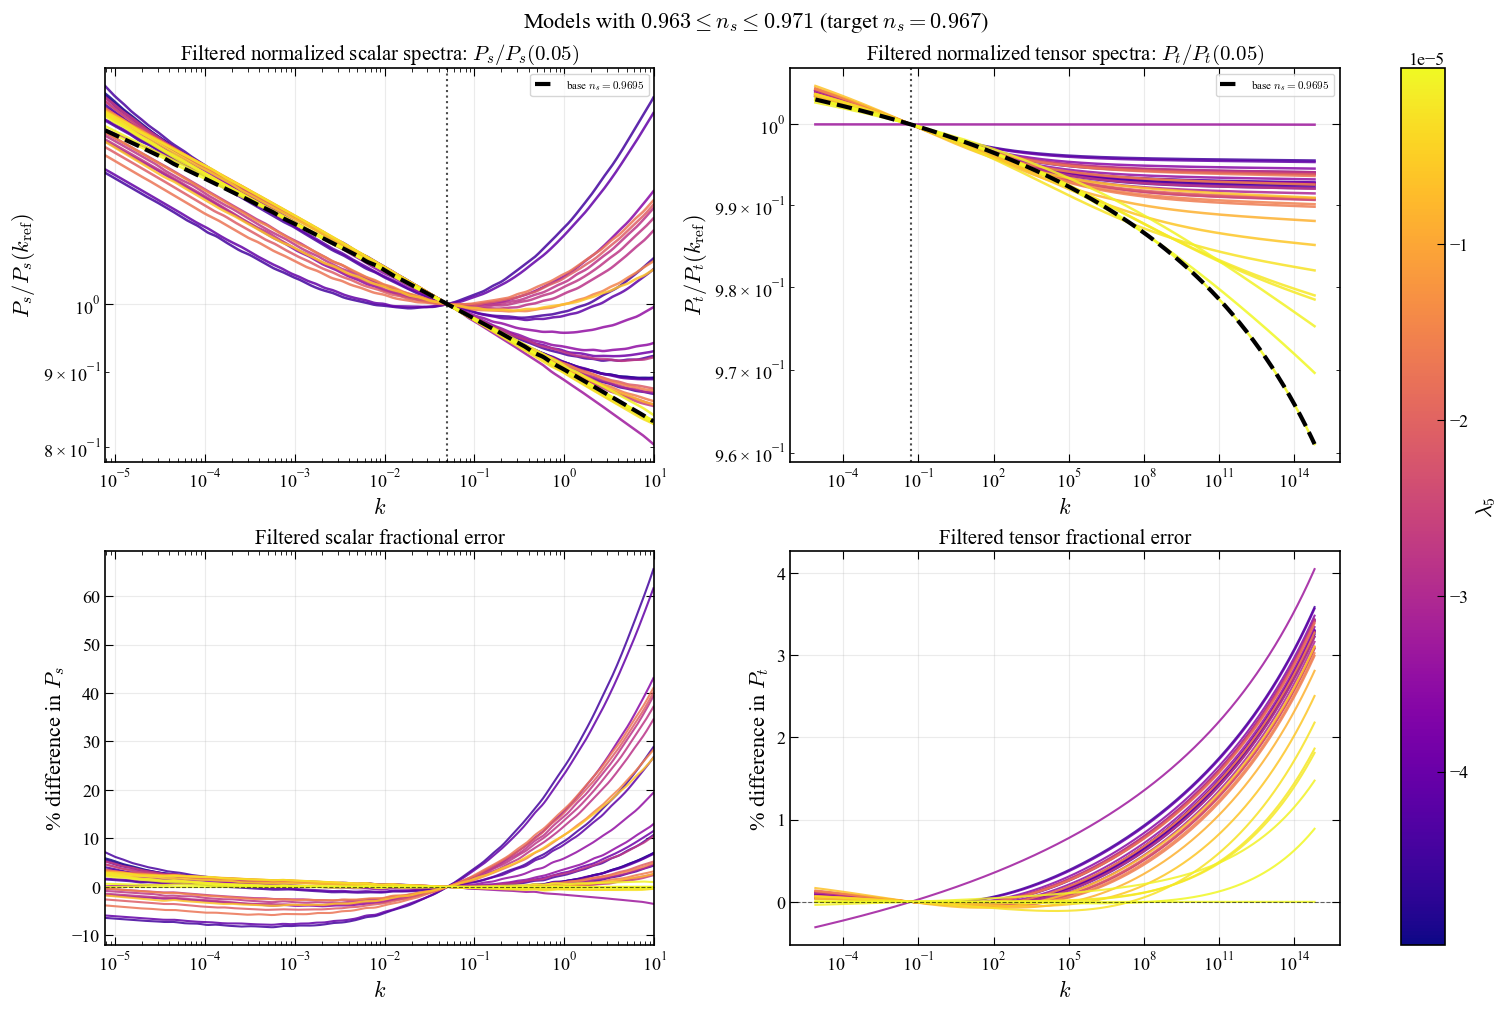


=== All models summary ===
Total loaded: 5
Base ns: 0.970677
Models in ns window [0.963, 0.971]: 5

=== Filtered models by ns cut ===
        lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
1.570437e-09 0.965270           -0.005408      0.985578     4.316017      0.433171     1.760993
3.257382e-09 0.965683           -0.004994      0.898652     3.870789      0.433004     1.760468
8.188894e-10 0.966374           -0.004303      0.746269     3.277676      0.426415     1.735608
6.100000e-10 0.970677            0.000000      0.000000     0.000000      0.000000     0.000000
1.817399e-09 0.970689            0.000011      0.001921     2.600425      0.392457     1.606747

=== Error shrink check (in percentages) ===
All models:
      mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
mean      0.526484     2.812981      0.337010     1.372763
max       0.985578     4.316017      0.433171     1.760993

Filtered models:
      mean_dPs_pct  max_dPs_pct  mean

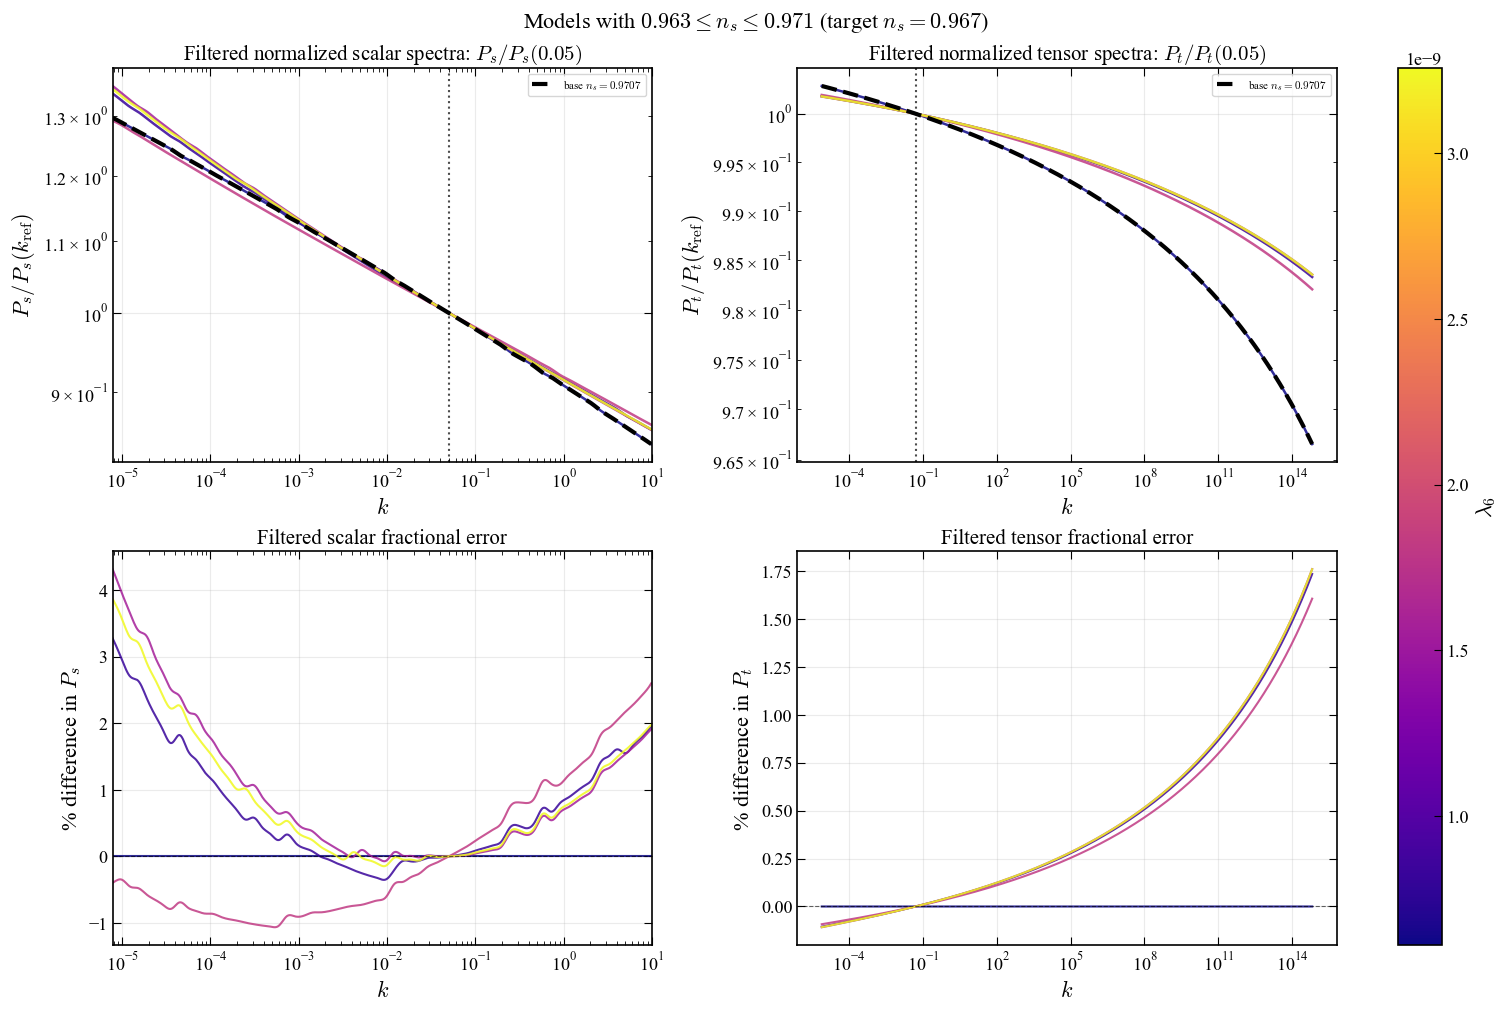

In [35]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)
lam6_values = get_param_values_from_dirs(9, "lam6", base_path_root)


stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX= -8.92461e-9,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs8_lam5_filtered_ns_spectra.png"
)

stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=9,
    lamX_values=lam6_values,
    baseX= 6.1e-10,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs9_lam6_filtered_ns_spectra.png"
)


## Accounting for Nshift

We apply the Nshift here for the random range of lam4 and lam5 parameters.

In [36]:
# def plot_k_shift_equivalence_scan_2x2(
#     NEQS,
#     lamX_values,
#     baseX,
#     base_path_root,
#     k_norm=0.05,
#     k_max_scalar=10.0,
#     cmap_name="plasma",
#     save_name=None,
# ):
  
#     scan_name, scan_symbol = SCAN_INFO[NEQS]

#     def sanitize_lam_values(vals):
#         return np.array(
#             [x[0] if isinstance(x, tuple) else x for x in vals],
#             dtype=float
#         )

#     def folder_for(value):
#         val_str = f"{value:.10e}"
#         return os.path.join(
#             base_path_root,
#             f"neqs{NEQS}",
#             f"{scan_name}_{val_str}"
#         )

#     def load_specs_local(value):
#         folder = folder_for(value)

#         s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
#         t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

#         k_s = s[:, 0]
#         Ps = np.abs(s[:, 1])

#         k_t = t[:, 0]
#         Pt = np.abs(t[:, 1])

#         k_s, Ps = prepare_increasing(k_s, Ps)
#         k_t, Pt = prepare_increasing(k_t, Pt)

#         return k_s, Ps, k_t, Pt

#     def get_original_N_end(value):
#         summary_file = os.path.join(
#             base_path_root,
#             f"neqs{NEQS}",
#             f"neqs{NEQS}_summary.csv"
#         )

#         summary_df = pd.read_csv(summary_file)

#         matches = summary_df.loc[
#             np.isclose(summary_df[scan_name], value)
#         ]

#         if len(matches) == 0:
#             raise ValueError(
#                 f"No summary row found for {scan_name}={value:.10e}"
#             )

#         return float(matches.iloc[0]["original_N_end"])

#     def normalize_at_k(k, P, k_ref):
#         k, P = prepare_increasing(k, P)

#         if not (k.min() <= k_ref <= k.max()):
#             raise ValueError(
#                 f"k_ref={k_ref} outside shifted k range "
#                 f"[{k.min():.3e}, {k.max():.3e}]"
#             )

#         P_ref = np.interp(k_ref, k, P)

#         if np.abs(P_ref) < 1e-30:
#             raise ValueError(f"Reference spectrum too small at k={k_ref}")

#         return k, P / P_ref, P_ref

#     def frac_on_base_grid(k_base, P_base, k_cmp, P_cmp, kmax=None):
#         k_base, P_base = prepare_increasing(k_base, P_base)
#         k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

#         xmin = max(k_base.min(), k_cmp.min())
#         xmax = min(k_base.max(), k_cmp.max())

#         if kmax is not None:
#             xmax = min(xmax, kmax)

#         mask = (k_base >= xmin) & (k_base <= xmax)

#         k_use = k_base[mask]
#         P_base_use = P_base[mask]
#         P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)

#         frac = (P_cmp_interp - P_base_use) / P_base_use

#         return k_use, frac

#     lam_vals = sanitize_lam_values(lamX_values)

#     # -----------------------------
#     # Base/reference
#     # -----------------------------
#     base_N_end = get_original_N_end(baseX)

#     k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs_local(baseX)

#     k_s_base, Ps_base_norm, _ = normalize_at_k(
#         k_s_base_raw, Ps_base_raw, k_norm
#     )

#     k_t_base, Pt_base_norm, _ = normalize_at_k(
#         k_t_base_raw, Pt_base_raw, k_norm
#     )

#     # -----------------------------
#     # Figure
#     # -----------------------------
#     fig, axes = plt.subplots(
#         2, 2,
#         figsize=(15, 10),
#         constrained_layout=True
#     )

#     ax_ps, ax_pt = axes[0]
#     ax_ps_err, ax_pt_err = axes[1]

#     cmap = plt.get_cmap(cmap_name)
#     norm = mcolors.Normalize(vmin=np.min(lam_vals), vmax=np.max(lam_vals))

#     rows = []

#     for value in lam_vals:

#         try:
#             model_N_end = get_original_N_end(value)
#             deltaN = model_N_end - base_N_end

#             k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(value)

#             # In your convention: a(N) ~ exp(-N),
#             # so N-shift corresponds to k -> k exp(-deltaN).
#             k_s_shifted = k_s_raw * np.exp(-deltaN)
#             k_t_shifted = k_t_raw * np.exp(-deltaN)

#             k_s, Ps_norm, _ = normalize_at_k(
#                 k_s_shifted, Ps_raw, k_norm
#             )

#             k_t, Pt_norm, _ = normalize_at_k(
#                 k_t_shifted, Pt_raw, k_norm
#             )

#             k_ps_err, frac_ps = frac_on_base_grid(
#                 k_s_base,
#                 Ps_base_norm,
#                 k_s,
#                 Ps_norm,
#                 kmax=k_max_scalar
#             )

#             k_pt_err, frac_pt = frac_on_base_grid(
#                 k_t_base,
#                 Pt_base_norm,
#                 k_t,
#                 Pt_norm,
#                 kmax=None
#             )

#             color = cmap(norm(value))

#             mask_s = k_s <= k_max_scalar

#             ax_ps.loglog(
#                 k_s[mask_s],
#                 Ps_norm[mask_s],
#                 color=color,
#                 lw=1.5,
#                 alpha=0.85,
#             )

#             ax_pt.loglog(
#                 k_t,
#                 Pt_norm,
#                 color=color,
#                 lw=1.5,
#                 alpha=0.85,
#             )

#             ax_ps_err.semilogx(
#                 k_ps_err,
#                 100.0 * frac_ps,
#                 color=color,
#                 lw=1.4,
#                 alpha=0.85,
#             )

#             ax_pt_err.semilogx(
#                 k_pt_err,
#                 100.0 * frac_pt,
#                 color=color,
#                 lw=1.4,
#                 alpha=0.85,
#             )

#             rows.append({
#                 scan_name: value,
#                 "original_N_end": model_N_end,
#                 "deltaN_from_base": deltaN,
#                 "exp_minus_deltaN": np.exp(-deltaN),

#                 "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
#                 "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),

#                 "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
#                 "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
#             })

#         except FileNotFoundError:
#             print(f"Missing files for {scan_name}={value:.5e}")

#         except ValueError as e:
#             print(f"Skipping {scan_name}={value:.5e}: {e}")

#     # -----------------------------
#     # Base overlays
#     # -----------------------------
#     mask_base_s = k_s_base <= k_max_scalar

#     ax_ps.loglog(
#         k_s_base[mask_base_s],
#         Ps_base_norm[mask_base_s],
#         color="black",
#         lw=3,
#         ls="--",
#         label=rf"base ${scan_symbol}={baseX:.2e}$",
#     )

#     ax_pt.loglog(
#         k_t_base,
#         Pt_base_norm,
#         color="black",
#         lw=3,
#         ls="--",
#         label=rf"base ${scan_symbol}={baseX:.2e}$",
#     )

#     for ax in [ax_ps_err, ax_pt_err]:
#         ax.axhline(
#             0.0,
#             color="black",
#             ls="--",
#             lw=0.8,
#             alpha=0.6,
#         )

#     ax_ps.axvline(k_norm, color="black", ls=":", alpha=0.7)
#     ax_pt.axvline(k_norm, color="black", ls=":", alpha=0.7)

#     # -----------------------------
#     # Labels
#     # -----------------------------
#     ax_ps.set_title(
#         rf"Shifted scalar spectra: $P_s/P_s({k_norm})$"
#     )

#     ax_pt.set_title(
#         rf"Shifted tensor spectra: $P_t/P_t({k_norm})$"
#     )

#     ax_ps_err.set_title(
#         r"Shifted scalar fractional error"
#     )

#     ax_pt_err.set_title(
#         r"Shifted tensor fractional error"
#     )

#     ax_ps.set_xlabel(r"shifted $k$")
#     ax_pt.set_xlabel(r"shifted $k$")
#     ax_ps_err.set_xlabel(r"$k$ on base grid")
#     ax_pt_err.set_xlabel(r"$k$ on base grid")

#     ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
#     ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")
#     ax_ps_err.set_ylabel(r"% difference in $P_s$")
#     ax_pt_err.set_ylabel(r"% difference in $P_t$")

#     ax_ps.set_xlim(k_s_base.min(), k_max_scalar)
#     ax_ps_err.set_xlim(k_s_base.min(), k_max_scalar)

#     for ax in axes.ravel():
#         ax.grid(True, alpha=0.25)
#         handles, labels = ax.get_legend_handles_labels()
#         if len(handles) > 0:
#             ax.legend(fontsize=8)

#     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#     fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

#     fig.suptitle(
#         rf"NEQS={NEQS}: spectra after $k \to k e^{{-\Delta N}}$ "
#         rf"relative to base ${scan_symbol}={baseX:.2e}$",
#         fontsize=16,
#     )

#     if save_name is None:
#         save_name = f"neqs{NEQS}_{scan_name}_all_kshifted_spectra_2x2.png"

# #     plt.savefig(save_name, dpi=300, bbox_inches="tight")
#     plt.show()

#     stats_df = pd.DataFrame(rows)

#     if not stats_df.empty:
#         print("\n=== Shifted spectra fractional-error summary ===")
#         print(
#             stats_df[[
#                 scan_name,
#                 "deltaN_from_base",
#                 "mean_dPs_pct",
#                 "max_dPs_pct",
#                 "mean_dPt_pct",
#                 "max_dPt_pct",
#             ]].to_string(index=False)
#         )

#     return stats_df
# # 


In [37]:
def plot_k_shift_equivalence_scan_2x2(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    k_norm=0.05,
    k_max_scalar=10.0,

    # NEW LIMITS
    frac_ylim=(-0.6, 0.6),
    scalar_ylim=None,
    tensor_ylim=None,

    cmap_name="plasma",
    save_name=None,
):

    # -------------------------------------------------
    # Publication-style plotting
    # -------------------------------------------------

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "Computer Modern Roman",
            "Times New Roman",
            "DejaVu Serif",
        ],

        "mathtext.fontset": "cm",

        "axes.labelsize": 16,
        "axes.titlesize": 15,
        "figure.titlesize": 18,

        "xtick.labelsize": 13,
        "ytick.labelsize": 13,

        "legend.fontsize": 11,

        "axes.linewidth": 1.2,

        "xtick.direction": "in",
        "ytick.direction": "in",

        "xtick.top": True,
        "ytick.right": True,

        "xtick.major.size": 6,
        "ytick.major.size": 6,

        "xtick.minor.size": 3,
        "ytick.minor.size": 3,

        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    # -------------------------------------------------
    # Helpers
    # -------------------------------------------------

    def sanitize_lam_values(vals):

        return np.array(
            [
                x[0] if isinstance(x, tuple) else x
                for x in vals
            ],
            dtype=float,
        )

    def folder_for(value):

        val_str = f"{value:.10e}"

        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_specs_local(value):

        folder = folder_for(value)

        s = np.loadtxt(
            os.path.join(
                folder,
                f"spec_s_neqs{NEQS}.dat"
            )
        )

        t = np.loadtxt(
            os.path.join(
                folder,
                f"spec_t_neqs{NEQS}.dat"
            )
        )

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        k_s, Ps = prepare_increasing(k_s, Ps)
        k_t, Pt = prepare_increasing(k_t, Pt)

        return k_s, Ps, k_t, Pt

    def get_original_N_end(value):

        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[scan_name], value)
        ]

        if len(matches) == 0:

            raise ValueError(
                f"No summary row found for "
                f"{scan_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):

        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):

            raise ValueError(
                f"k_ref={k_ref} outside shifted k range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:

            raise ValueError(
                f"Reference spectrum too small at k={k_ref}"
            )

        return k, P / P_ref, P_ref

    def frac_on_base_grid(
        k_base,
        P_base,
        k_cmp,
        P_cmp,
        kmax=None,
    ):

        k_base, P_base = prepare_increasing(
            k_base,
            P_base,
        )

        k_cmp, P_cmp = prepare_increasing(
            k_cmp,
            P_cmp,
        )

        xmin = max(k_base.min(), k_cmp.min())
        xmax = min(k_base.max(), k_cmp.max())

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (
            (k_base >= xmin)
            &
            (k_base <= xmax)
        )

        k_use = k_base[mask]

        P_base_use = P_base[mask]

        P_cmp_interp = np.interp(
            k_use,
            k_cmp,
            P_cmp,
        )

        frac = (
            (P_cmp_interp - P_base_use)
            /
            P_base_use
        )

        return k_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    # -------------------------------------------------
    # Base/reference
    # -------------------------------------------------

    base_N_end = get_original_N_end(baseX)

    (
        k_s_base_raw,
        Ps_base_raw,
        k_t_base_raw,
        Pt_base_raw,
    ) = load_specs_local(baseX)

    k_s_base, Ps_base_norm, _ = normalize_at_k(
        k_s_base_raw,
        Ps_base_raw,
        k_norm,
    )

    k_t_base, Pt_base_norm, _ = normalize_at_k(
        k_t_base_raw,
        Pt_base_raw,
        k_norm,
    )

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.5, 9.5),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    cmap = plt.get_cmap(cmap_name)

    norm = mcolors.Normalize(
        vmin=np.min(lam_vals),
        vmax=np.max(lam_vals),
    )

    rows = []

    # -------------------------------------------------
    # Loop over models
    # -------------------------------------------------

    for value in lam_vals:

        try:

            model_N_end = get_original_N_end(value)

            deltaN = model_N_end - base_N_end

            (
                k_s_raw,
                Ps_raw,
                k_t_raw,
                Pt_raw,
            ) = load_specs_local(value)

            k_s_shifted = (
                k_s_raw * np.exp(-deltaN)
            )

            k_t_shifted = (
                k_t_raw * np.exp(-deltaN)
            )

            k_s, Ps_norm, _ = normalize_at_k(
                k_s_shifted,
                Ps_raw,
                k_norm,
            )

            k_t, Pt_norm, _ = normalize_at_k(
                k_t_shifted,
                Pt_raw,
                k_norm,
            )

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                kmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                kmax=None,
            )

            color = cmap(norm(value))

            mask_s = k_s <= k_max_scalar

            # -----------------------------------------
            # Scalar spectra
            # -----------------------------------------

            ax_ps.loglog(
                k_s[mask_s],
                Ps_norm[mask_s],
                color=color,
                lw=1.25,
                alpha=0.75,
            )

            # -----------------------------------------
            # Tensor spectra
            # -----------------------------------------

            ax_pt.loglog(
                k_t,
                Pt_norm,
                color=color,
                lw=1.25,
                alpha=0.75,
            )

            # -----------------------------------------
            # Scalar fractional error
            # -----------------------------------------

            ax_ps_err.semilogx(
                k_ps_err,
                100.0 * frac_ps,
                color=color,
                lw=1.1,
                alpha=0.75,
            )

            # -----------------------------------------
            # Tensor fractional error
            # -----------------------------------------

            ax_pt_err.semilogx(
                k_pt_err,
                100.0 * frac_pt,
                color=color,
                lw=1.1,
                alpha=0.75,
            )

            rows.append({

                scan_name: value,

                "original_N_end":
                    model_N_end,

                "deltaN_from_base":
                    deltaN,

                "exp_minus_deltaN":
                    np.exp(-deltaN),

                "mean_dPs_pct":
                    100.0 * np.nanmean(frac_ps),

                "max_dPs_pct":
                    100.0 * np.nanmax(
                        np.abs(frac_ps)
                    ),

                "mean_dPt_pct":
                    100.0 * np.nanmean(frac_pt),

                "max_dPt_pct":
                    100.0 * np.nanmax(
                        np.abs(frac_pt)
                    ),
            })

        except FileNotFoundError:

            print(
                f"Missing files for "
                f"{scan_name}={value:.5e}"
            )

        except ValueError as e:

            print(
                f"Skipping "
                f"{scan_name}={value:.5e}: {e}"
            )

    # -------------------------------------------------
    # Base overlays
    # -------------------------------------------------

    mask_base_s = k_s_base <= k_max_scalar

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=2.4,
        ls="--",
        label=rf"Reference "
              rf"${scan_symbol}={baseX:.2e}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=2.4,
        ls="--",
        label=rf"Reference "
              rf"${scan_symbol}={baseX:.2e}$",
    )

    # -------------------------------------------------
    # Reference lines
    # -------------------------------------------------

    for ax in [ax_ps_err, ax_pt_err]:

        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.6,
        )

    ax_ps.axvline(
        k_norm,
        color="black",
        ls=":",
        lw=1.1,
        alpha=0.7,
    )

    ax_pt.axvline(
        k_norm,
        color="black",
        ls=":",
        lw=1.1,
        alpha=0.7,
    )

    # -------------------------------------------------
    # Titles
    # -------------------------------------------------

    ax_ps.set_title(r"Scalar spectra")

    ax_pt.set_title(r"Tensor spectra")

    ax_ps_err.set_title(
        r"Scalar fractional differences"
    )

    ax_pt_err.set_title(
        r"Tensor fractional differences"
    )

    # -------------------------------------------------
    # Labels
    # -------------------------------------------------

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")

    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(
        rf"$P_s/P_s(k={k_norm})$"
    )

    ax_pt.set_ylabel(
        rf"$P_t/P_t(k={k_norm})$"
    )

    ax_ps_err.set_ylabel(
        r"$100 \times \Delta P_s/P_s \; (\%)$"
    )

    ax_pt_err.set_ylabel(
        r"$100 \times \Delta P_t/P_t \; (\%)$"
    )

    # -------------------------------------------------
    # Limits
    # -------------------------------------------------

    # Scalar k-ranges
    ax_ps.set_xlim(
        k_s_base.min(),
        k_max_scalar,
    )

    ax_ps_err.set_xlim(
        k_s_base.min(),
        k_max_scalar,
    )

    # Tensor k-ranges
    ax_pt.set_xlim(
        k_t_base.min(),
        k_t_base.max(),
    )

    ax_pt_err.set_xlim(
        k_t_base.min(),
        k_t_base.max(),
    )

    # Same residual limits
    ax_ps_err.set_ylim(*frac_ylim)
    ax_pt_err.set_ylim(*frac_ylim)

    # Optional spectra limits
    if scalar_ylim is not None:
        ax_ps.set_ylim(*scalar_ylim)

    if tensor_ylim is not None:
        ax_pt.set_ylim(*tensor_ylim)

    # -------------------------------------------------
    # Final axis styling
    # -------------------------------------------------

    for ax in axes.ravel():

        ax.minorticks_on()

        ax.grid(
            True,
            which="major",
            alpha=0.25,
            lw=0.8,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
            lw=0.5,
        )

        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
        )

        handles, labels = (
            ax.get_legend_handles_labels()
        )

        if len(handles) > 0:

            ax.legend(
                frameon=False,
                loc="best",
                handlelength=2.6,
                borderpad=0.4,
            )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        pad=0.025,
        fraction=0.035,
    )

    cbar.set_label(
        rf"${scan_symbol}$",
        fontsize=16,
    )

    cbar.ax.tick_params(
        labelsize=12,
        direction="in",
    )

    # -------------------------------------------------
    # Figure title
    # -------------------------------------------------

    fig.suptitle(
        rf"NEQS={NEQS}: spectra shifted "
        rf"relative to the reference model",
        y=1.02,
    )

    # -------------------------------------------------
    # Save
    # -------------------------------------------------

    if save_name is None:

        save_name = (
            f"neqs{NEQS}_"
            f"{scan_name}_"
            f"all_kshifted_spectra_2x2.png"
        )

    # plt.savefig(save_name)

    plt.show()

    # -------------------------------------------------
    # Summary dataframe
    # -------------------------------------------------

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:

        print(
            "\n=== Shifted spectra "
            "fractional-error summary ==="
        )

        print(
            stats_df[[
                scan_name,
                "deltaN_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    return stats_df

I want to compare this actually to NEQs=6 base so I will need to load that actually:

Skipping lam5=-4.46186e-05: k_ref=0.05 outside shifted k range [3.947e-01, 3.277e+19]
Skipping lam5=-4.08166e-05: k_ref=0.05 outside shifted k range [4.055e-01, 3.367e+19]
Skipping lam5=-3.58662e-05: k_ref=0.05 outside shifted k range [1.529e-01, 1.270e+19]
Skipping lam5=-3.28122e-05: k_ref=0.05 outside shifted k range [5.555e+62, 4.613e+82]
Skipping lam5=-2.83727e-05: k_ref=0.05 outside shifted k range [1.351e-01, 1.122e+19]
Skipping lam5=-2.78710e-05: k_ref=0.05 outside shifted k range [2.268e-01, 1.884e+19]
Skipping lam5=-2.77860e-05: k_ref=0.05 outside shifted k range [1.861e-01, 1.546e+19]
Skipping lam5=-2.09680e-05: k_ref=0.05 outside shifted k range [5.881e-01, 4.884e+19]
Skipping lam5=-1.71598e-05: k_ref=0.05 outside shifted k range [1.271e+00, 1.056e+20]
Skipping lam5=-1.46181e-05: k_ref=0.05 outside shifted k range [4.841e-01, 4.020e+19]
Skipping lam5=-6.51124e-06: k_ref=0.05 outside shifted k range [6.137e+00, 5.096e+20]


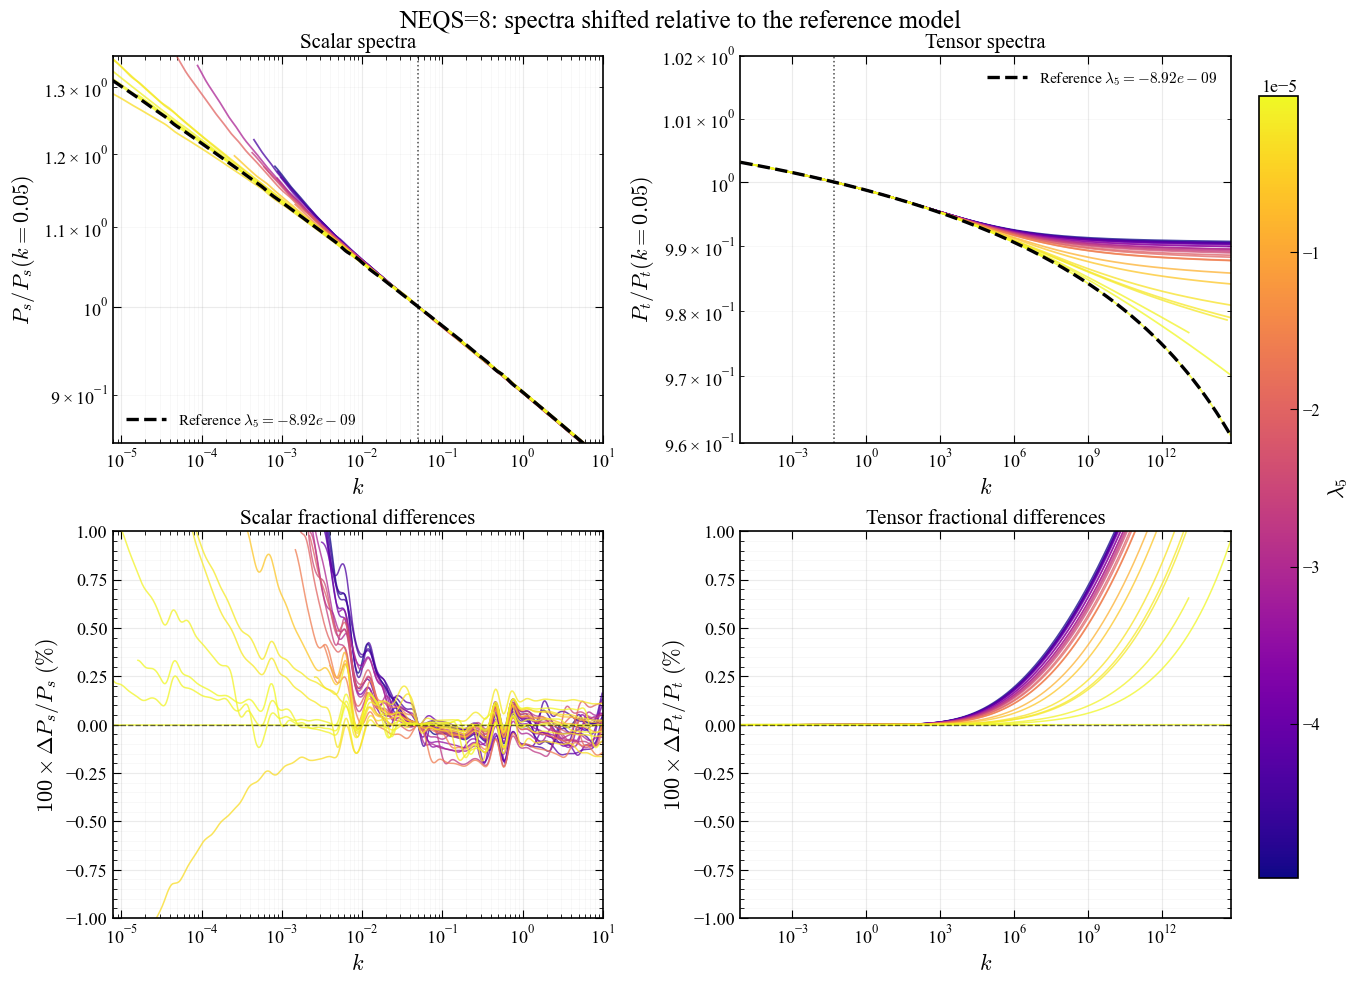


=== Shifted spectra fractional-error summary ===
         lam5  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-4.984906e-05         -4.657846      0.438831     3.777212      0.636492     3.087643
-4.584023e-05         -4.738130      0.405784     3.364520      0.629667     3.068178
-4.418407e-05         -8.040875     -0.041671     0.186842      0.682677     3.066452
-4.387958e-05         -4.055105      0.639235     4.972253      0.614834     3.056027
-4.346710e-05         -5.661344      0.206128     1.651004      0.639517     3.057657
-4.192331e-05         -4.825258      0.288608     2.884476      0.622189     3.046941
-4.142265e-05         -7.981875     -0.001260     0.150484      0.674689     3.051009
-3.948907e-05         -5.998482      0.051365     0.943146      0.635029     3.035163
-3.493937e-05         -6.497676      0.032405     0.595864      0.630491     3.005815
-3.458297e-05         -7.515283     -0.021640     0.271028      0.646836     3.005592
-3.0

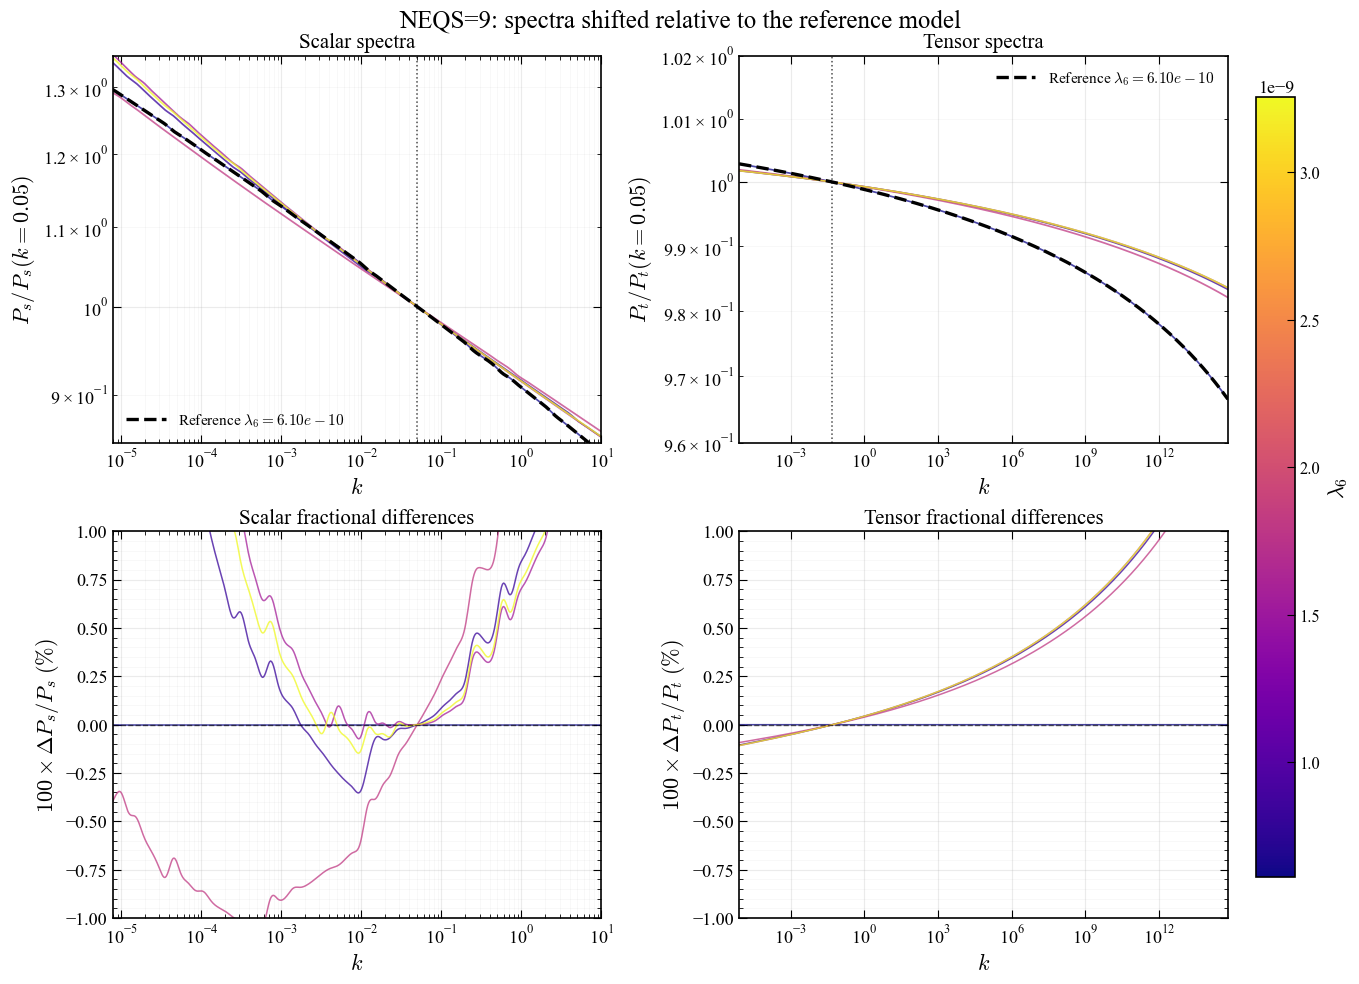


=== Shifted spectra fractional-error summary ===
        lam6  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
6.100000e-10               0.0      0.000000     0.000000      0.000000     0.000000
8.188894e-10               0.0      0.746269     3.277676      0.426415     1.735608
1.570437e-09               0.0      0.985578     4.316017      0.433171     1.760993
1.817399e-09               0.0      0.001921     2.600425      0.392457     1.606747
3.257382e-09               0.0      0.898652     3.870789      0.433004     1.760468


In [38]:
shift_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,

    k_norm=0.05,
    k_max_scalar=10.0,

#     frac_ylim=(-0.6, 0.6),
    frac_ylim=(-1, 1),

    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),

    cmap_name="plasma",

    save_name="neqs8_lam5_shifted_spectra_2x2.png",
)


shift_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=9,
    lamX_values=lam6_values,
    baseX=6.1e-10,
    base_path_root=base_path_root,

    k_norm=0.05,
    k_max_scalar=10.0,

#     frac_ylim=(-0.6, 0.6),
    frac_ylim=(-1, 1),

    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),

    cmap_name="plasma",

    save_name="neqs9_lam6_shifted_spectra_2x2.png",
)

## Compare now to NEQs=6 base

In [39]:
# def plot_all_neqs_kshift_to_lam3_base_2x2(
#     base_path_root,
#     lam_values_by_neqs,
#     ref_NEQS=6,
#     ref_param="lam3",
#     ref_value=-4.6097100000e-6,
#     k_norm=0.05,
#     k_max_scalar=10.0,
#     skip_zero=True,
#     zero_tol=1e-30,
#     save_name=None,
# ):
    
#     colors_by_neqs = {
#     5: "pink",
#     6: "turquoise",
#     7: "plum",
#     8: "mediumslateblue",
# }

#     def folder_for(NEQS, param_name, value):
#         val_str = f"{value:.10e}"
#         return os.path.join(
#             base_path_root,
#             f"neqs{NEQS}",
#             f"{param_name}_{val_str}",
#         )

#     def load_specs_local(NEQS, param_name, value):
#         folder = folder_for(NEQS, param_name, value)

#         s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
#         t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

#         k_s = s[:, 0]
#         Ps = np.abs(s[:, 1])

#         k_t = t[:, 0]
#         Pt = np.abs(t[:, 1])

#         k_s, Ps = prepare_increasing(k_s, Ps)
#         k_t, Pt = prepare_increasing(k_t, Pt)

#         return k_s, Ps, k_t, Pt

#     def get_original_N_end(NEQS, param_name, value):
#         summary_file = os.path.join(
#             base_path_root,
#             f"neqs{NEQS}",
#             f"neqs{NEQS}_summary.csv",
#         )

#         summary_df = pd.read_csv(summary_file)

#         matches = summary_df.loc[
#             np.isclose(summary_df[param_name], value)
#         ]

#         if len(matches) == 0:
#             raise ValueError(
#                 f"No summary row found for NEQS={NEQS}, "
#                 f"{param_name}={value:.10e}"
#             )

#         return float(matches.iloc[0]["original_N_end"])

#     def normalize_at_k(k, P, k_ref):
#         k, P = prepare_increasing(k, P)

#         if not (k.min() <= k_ref <= k.max()):
#             raise ValueError(
#                 f"k_ref={k_ref} outside shifted k range "
#                 f"[{k.min():.3e}, {k.max():.3e}]"
#             )

#         P_ref = np.interp(k_ref, k, P)

#         if np.abs(P_ref) < 1e-30:
#             raise ValueError(f"Reference spectrum too small at k={k_ref}")

#         return k, P / P_ref

#     def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmax=None):
#         k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
#         k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

#         xmin = max(k_ref_grid.min(), k_cmp.min())
#         xmax = min(k_ref_grid.max(), k_cmp.max())

#         if kmax is not None:
#             xmax = min(xmax, kmax)

#         mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)

#         k_use = k_ref_grid[mask]
#         P_ref_use = P_ref_norm[mask]
#         P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

#         frac = (P_cmp_interp - P_ref_use) / P_ref_use

#         return k_use, frac

#     # -------------------------------------------------
#     # Reference: NEQS=6 lam3 base
#     # -------------------------------------------------

#     ref_N_end = get_original_N_end(
#         ref_NEQS,
#         ref_param,
#         ref_value,
#     )

#     k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
#         ref_NEQS,
#         ref_param,
#         ref_value,
#     )

#     k_s_ref, Ps_ref_norm = normalize_at_k(
#         k_s_ref_raw,
#         Ps_ref_raw,
#         k_norm,
#     )

#     k_t_ref, Pt_ref_norm = normalize_at_k(
#         k_t_ref_raw,
#         Pt_ref_raw,
#         k_norm,
#     )

#     # -------------------------------------------------
#     # Figure
#     # -------------------------------------------------

#     fig, axes = plt.subplots(
#         2, 2,
#         figsize=(15, 10),
#         constrained_layout=True,
#     )

#     ax_ps, ax_pt = axes[0]
#     ax_ps_err, ax_pt_err = axes[1]

#     # Reference overlays
#     mask_ref_s = k_s_ref <= k_max_scalar

#     ax_ps.loglog(
#         k_s_ref[mask_ref_s],
#         Ps_ref_norm[mask_ref_s],
#         color="black",
#         lw=3,
#         ls="-",
#         label=rf"NEQS={ref_NEQS} base",
#     )

#     ax_pt.loglog(
#         k_t_ref,
#         Pt_ref_norm,
#         color="black",
#         lw=3,
#         ls="-",
#         label=rf"NEQS={ref_NEQS} base",
#     )

#     rows = []

#     # -------------------------------------------------
#     # Loop over all NEQS scans
#     # -------------------------------------------------

#     for NEQS, lam_values in lam_values_by_neqs.items():

#         param_name, _ = SCAN_INFO[NEQS]
#         color = colors_by_neqs.get(NEQS, None)

#         for item in lam_values:

#             value = item[0] if isinstance(item, tuple) else item
#             value = float(value)

#             if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
#                 continue

#             try:
#                 model_N_end = get_original_N_end(
#                     NEQS,
#                     param_name,
#                     value,
#                 )

#                 deltaN = model_N_end - ref_N_end

#                 k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
#                     NEQS,
#                     param_name,
#                     value,
#                 )

#                 k_s_shifted = k_s_raw * np.exp(-deltaN)
#                 k_t_shifted = k_t_raw * np.exp(-deltaN)

#                 k_s, Ps_norm = normalize_at_k(
#                     k_s_shifted,
#                     Ps_raw,
#                     k_norm,
#                 )

#                 k_t, Pt_norm = normalize_at_k(
#                     k_t_shifted,
#                     Pt_raw,
#                     k_norm,
#                 )

#                 # fractional errors relative to NEQS=6 base
#                 k_ps_err, frac_ps = frac_on_ref_grid(
#                     k_s_ref,
#                     Ps_ref_norm,
#                     k_s,
#                     Ps_norm,
#                     kmax=k_max_scalar,
#                 )

#                 k_pt_err, frac_pt = frac_on_ref_grid(
#                     k_t_ref,
#                     Pt_ref_norm,
#                     k_t,
#                     Pt_norm,
#                     kmax=None,
#                 )

#                 mask_s = k_s <= k_max_scalar

#                 ax_ps.loglog(
#                     k_s[mask_s],
#                     Ps_norm[mask_s],
#                     color=color,
#                     lw=1.1,
#                     alpha=0.55,
#                     ls="--",
#                 )

#                 ax_pt.loglog(
#                     k_t,
#                     Pt_norm,
#                     color=color,
#                     lw=1.1,
#                     alpha=0.55,
#                     ls="--",
#                 )

#                 ax_ps_err.semilogx(
#                     k_ps_err,
#                     100.0 * frac_ps,
#                     color=color,
#                     lw=1.0,
#                     alpha=0.55,
#                     ls="--",
#                 )

#                 ax_pt_err.semilogx(
#                     k_pt_err,
#                     100.0 * frac_pt,
#                     color=color,
#                     lw=1.0,
#                     alpha=0.55,
#                     ls="--",
#                 )

#                 rows.append({
#                     "NEQS": NEQS,
#                     "param_name": param_name,
#                     "value": value,
#                     "original_N_end": model_N_end,
#                     "deltaN_from_ref_base": deltaN,
#                     "exp_minus_deltaN": np.exp(-deltaN),

#                     "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
#                     "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),

#                     "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
#                     "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
#                 })

#             except FileNotFoundError:
#                 print(
#                     f"Missing files for NEQS={NEQS}, "
#                     f"{param_name}={value:.5e}"
#                 )

#             except ValueError as e:
#                 print(
#                     f"Skipping NEQS={NEQS}, "
#                     f"{param_name}={value:.5e}: {e}"
#                 )

#     # -------------------------------------------------
#     # Styling
#     # -------------------------------------------------

#     for ax in [ax_ps_err, ax_pt_err]:
#         ax.axhline(
#             0.0,
#             color="black",
#             ls="--",
#             lw=0.8,
#             alpha=0.6,
#         )

#     ax_ps.axvline(k_norm, color="black", ls=":", alpha=0.6)
#     ax_pt.axvline(k_norm, color="black", ls=":", alpha=0.6)

#     # Legend proxies
#     for NEQS, color in colors_by_neqs.items():
#         if NEQS in lam_values_by_neqs:
#             ax_ps.plot(
#                 [],
#                 [],
#                 color=color,
#                 ls="--",
#                 lw=2,
#                 label=rf"NEQS={NEQS} shifted models",
#             )

#     ax_ps.set_title(
#         rf"Shifted scalar spectra vs NEQS={ref_NEQS} base"
#     )

#     ax_pt.set_title(
#         rf"Shifted tensor spectra vs NEQS={ref_NEQS} base"
#     )

#     ax_ps_err.set_title(
#         rf"Scalar fractional error vs NEQS={ref_NEQS} base"
#     )

#     ax_pt_err.set_title(
#         rf"Tensor fractional error vs NEQS={ref_NEQS} base"
#     )

#     ax_ps.set_xlabel(r"shifted $k$")
#     ax_pt.set_xlabel(r"shifted $k$")
#     ax_ps_err.set_xlabel(rf"$k$ on NEQS={ref_NEQS} base grid")
#     ax_pt_err.set_xlabel(rf"$k$ on NEQS={ref_NEQS} base grid")

#     ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
#     ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")
#     ax_ps_err.set_ylabel(r"% difference in $P_s$")
#     ax_pt_err.set_ylabel(r"% difference in $P_t$")

#     ax_ps.set_xlim(k_s_ref.min(), k_max_scalar)
#     ax_ps_err.set_xlim(k_s_ref.min(), k_max_scalar)

#     for ax in axes.ravel():
#         ax.grid(True, alpha=0.3)
#         handles, labels = ax.get_legend_handles_labels()
#         if len(handles) > 0:
#             ax.legend(fontsize=8)

#     fig.suptitle(
#         rf"All lam3/lam4/lam5 models shifted to NEQS={ref_NEQS} base "
#         rf"using $k \to k e^{{-\Delta N}}$",
#         fontsize=16,
#     )

#     if save_name is None:
#         save_name = "all_neqs_lamX_shifted_to_neqs{ref_NEQS}_base_spectra_2x2.png"

# #     plt.savefig(save_name, dpi=300, bbox_inches="tight")
#     plt.show()

#     stats_df = pd.DataFrame(rows)

#     if not stats_df.empty:
#         print("\n=== Cross-NEQS shifted spectra summary ===")
#         print(
#             stats_df[[
#                 "NEQS",
#                 "param_name",
#                 "value",
#                 "deltaN_from_ref_base",
#                 "mean_dPs_pct",
#                 "max_dPs_pct",
#                 "mean_dPt_pct",
#                 "max_dPt_pct",
#             ]].to_string(index=False)
#         )

#     return stats_df

In [40]:
def plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=-4.6097100000e-6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    zero_tol=1e-30,
    frac_ylim=(-0.6, 0.6),
    scalar_ylim=None,
    tensor_ylim=None,
    save_name=None,
):

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.labelsize": 16,
        "axes.titlesize": 15,
        "figure.titlesize": 18,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 11,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    colors_by_neqs = {
        5: "pink",
        6: "turquoise",
        7: "plum",
        8: "mediumslateblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{param_name}_{val_str}")

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, {param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside shifted k range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmax=None):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)

        k_use = k_ref_grid[mask]
        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    # -------------------------------------------------
    # Reference model
    # -------------------------------------------------

    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.5, 9.5),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    mask_ref_s = k_s_ref <= k_max_scalar

    ax_ps.loglog(
        k_s_ref[mask_ref_s],
        Ps_ref_norm[mask_ref_s],
        color="black",
        lw=2.4,
        ls="-",
        label=rf"NEQS={ref_NEQS} reference",
    )

    ax_pt.loglog(
        k_t_ref,
        Pt_ref_norm,
        color="black",
        lw=2.4,
        ls="-",
        label=rf"NEQS={ref_NEQS} reference",
    )

    rows = []

    for NEQS, lam_values in lam_values_by_neqs.items():

        param_name, _ = SCAN_INFO[NEQS]
        color = colors_by_neqs.get(NEQS, None)

        for item in lam_values:

            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
                    NEQS,
                    param_name,
                    value,
                )

                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s, Ps_norm = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t, Pt_norm = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_err, frac_ps = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s,
                    Ps_norm,
                    kmax=k_max_scalar,
                )

                k_pt_err, frac_pt = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t,
                    Pt_norm,
                    kmax=None,
                )

                mask_s = k_s <= k_max_scalar

                ax_ps.loglog(
                    k_s[mask_s],
                    Ps_norm[mask_s],
                    color=color,
                    lw=1.25,
                    alpha=0.65,
                    ls="--",
                )

                ax_pt.loglog(
                    k_t,
                    Pt_norm,
                    color=color,
                    lw=1.25,
                    alpha=0.65,
                    ls="--",
                )

                ax_ps_err.semilogx(
                    k_ps_err,
                    100.0 * frac_ps,
                    color=color,
                    lw=1.1,
                    alpha=0.65,
                    ls="--",
                )

                ax_pt_err.semilogx(
                    k_pt_err,
                    100.0 * frac_pt,
                    color=color,
                    lw=1.1,
                    alpha=0.65,
                    ls="--",
                )

                rows.append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "exp_minus_deltaN": np.exp(-deltaN),
                    "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                    "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                    "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                    "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")

    # -------------------------------------------------
    # Styling
    # -------------------------------------------------

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.6)

    ax_ps.axvline(k_norm, color="black", ls=":", alpha=0.6)
    ax_pt.axvline(k_norm, color="black", ls=":", alpha=0.6)

    for NEQS, color in colors_by_neqs.items():
        if NEQS in lam_values_by_neqs:
            ax_ps.plot([], [], color=color, ls="--", lw=2, label=rf"NEQS={NEQS}")

    ax_ps.set_title(r"Scalar spectra")
    ax_pt.set_title(r"Tensor spectra")
    ax_ps_err.set_title(r"Scalar fractional differences")
    ax_pt_err.set_title(r"Tensor fractional differences")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")
    ax_ps_err.set_ylabel(r"$100 \times \Delta P_s/P_s \; (\%)$")
    ax_pt_err.set_ylabel(r"$100 \times \Delta P_t/P_t \; (\%)$")

    # -------------------------------------------------
    # Limits: k-limits plus y-limits
    # -------------------------------------------------

    ax_ps.set_xlim(k_s_ref.min(), k_max_scalar)
    ax_ps_err.set_xlim(k_s_ref.min(), k_max_scalar)

    ax_pt.set_xlim(k_t_ref.min(), k_t_ref.max())
    ax_pt_err.set_xlim(k_t_ref.min(), k_t_ref.max())

    ax_ps_err.set_ylim(*frac_ylim)
    ax_pt_err.set_ylim(*frac_ylim)

    if scalar_ylim is not None:
        ax_ps.set_ylim(*scalar_ylim)

    if tensor_ylim is not None:
        ax_pt.set_ylim(*tensor_ylim)

    for ax in axes.ravel():

        ax.minorticks_on()

        ax.grid(True, which="major", alpha=0.25, lw=0.8)
        ax.grid(True, which="minor", alpha=0.12, lw=0.5)

        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
        )

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                loc="best",
                handlelength=2.6,
                borderpad=0.4,
            )

    fig.suptitle(
        rf"Spectra shifted to NEQS={ref_NEQS} reference model",
        y=1.02,
    )

    if save_name is None:
        save_name = (
            f"all_neqs_lamX_shifted_to_neqs"
            f"{ref_NEQS}_base_spectra_2x2.png"
        )

    plt.savefig(save_name)
    plt.show()

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:
        print("\n=== Cross-NEQS shifted spectra summary ===")
        print(
            stats_df[[
                "NEQS",
                "param_name",
                "value",
                "deltaN_from_ref_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    return stats_df


Summary for NEQS=6, parameter=lam3
Total models found: 39
Parameter range: -5.385e-05 to -4.124e-07


Summary for NEQS=7, parameter=lam4
Total models found: 40
Parameter range: -6.014e-08 to 3.499e-07


Summary for NEQS=8, parameter=lam5
Total models found: 5
Parameter range: -8.108e-07 to 0.000e+00


Summary for NEQS=9, parameter=lam6
Total models found: 5
Parameter range: 6.100e-10 to 3.257e-09



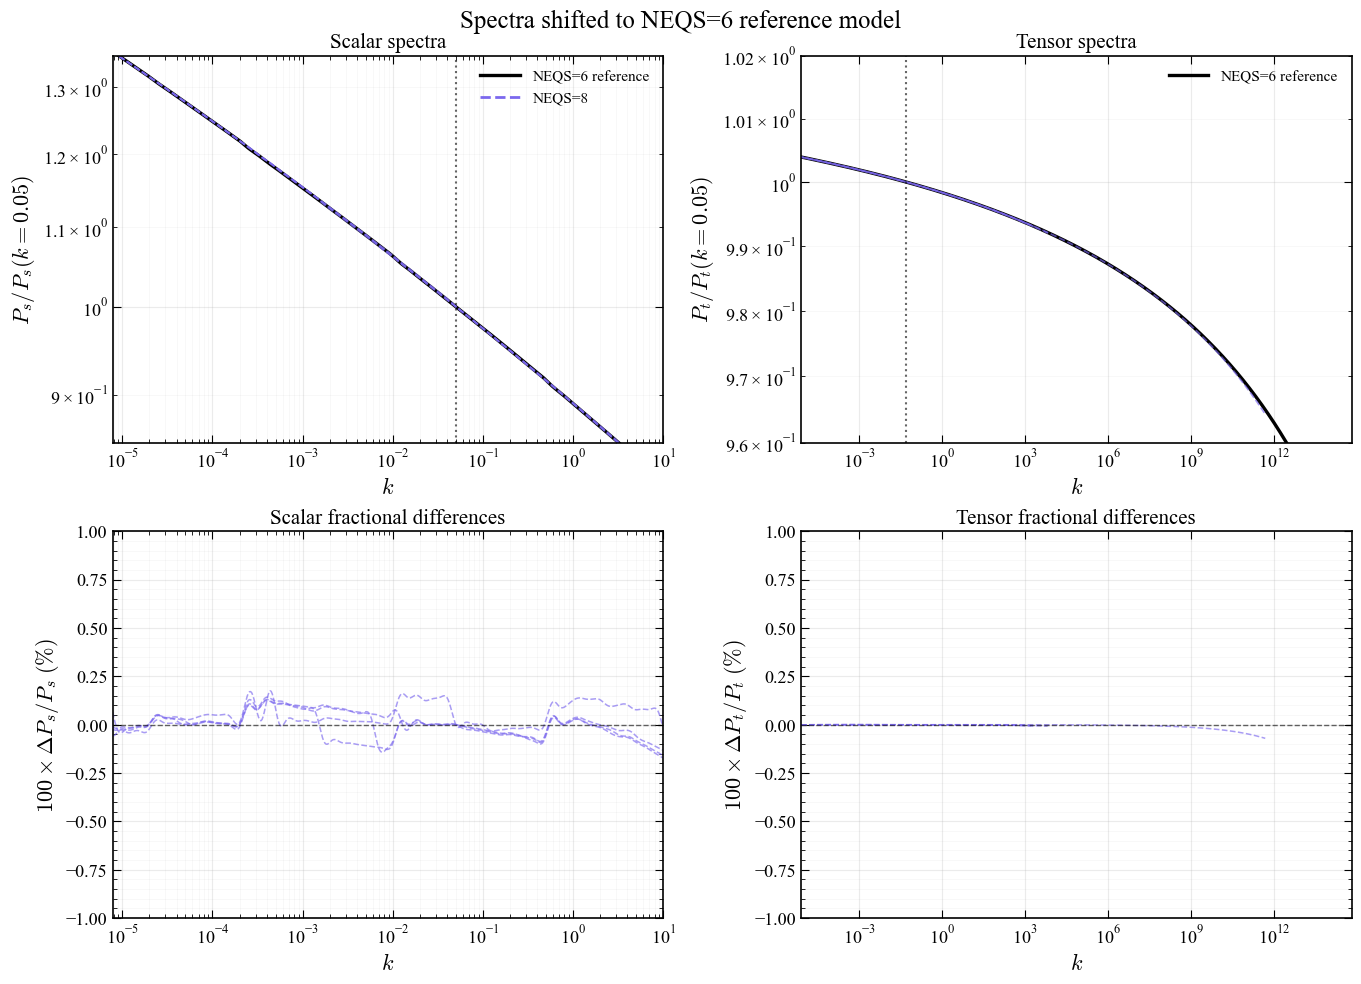


=== Cross-NEQS shifted spectra summary ===
 NEQS param_name         value      n_s  deltaN_from_ref_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
    8       lam5 -8.107768e-07 0.961332             26.707875     -0.012892     0.170904     -0.000640     0.005644
    8       lam5 -7.638593e-07 0.962601             26.423669      0.009162     0.159052     -0.000685     0.006066
    8       lam5 -6.042166e-07 0.966596             25.298850      0.003826     0.142481     -0.000850     0.007577
    8       lam5 -8.924610e-09 0.969485              7.186161      0.050031     0.175395     -0.006763     0.070482


In [59]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam3_values = get_param_values_from_dirs(6, "lam3", base_path_root)
lam4_values = get_param_values_from_dirs(7, "lam4", base_path_root)
lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)
lam6_values = get_param_values_from_dirs(9, "lam6", base_path_root)

base6 = -4.6097100000e-6 #for lam3 runs 
base7 = 6.87065e-08
base8 = -8.92461e-9
base9 = 6.1e-10


# lam_values_by_neqs = {
#     5: lam2_values,
#     6: lam3_values,
#     7: lam4_values,
#     8: lam5_values,
# }

#looking at random lam4 and lam5
lam_values_by_neqs = {
#     6: lam3_values,
    8: lam5_values,
}



# all_shift_2x2_df = plot_all_neqs_kshift_to_lam3_base_2x2(
#     base_path_root=base_path_root,
#     lam_values_by_neqs=lam_values_by_neqs,
#     ref_NEQS=6,
#     ref_param="lam3",
#     ref_value=base6,
#     k_norm=0.05,
#     k_max_scalar=10.0,
#     skip_zero=True,

#     # new y-limits
#     frac_ylim=(-1, 1),
#     scalar_ylim=(0.85, 1.35),
#     tensor_ylim=(0.96, 1.02),

#     save_name="neqs6and8_lamX_shifted_to_neqs6_base_spectra_2x2.png",
# )

all_shift_2x2_df = plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=base6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,

    # new y-limits
    frac_ylim=(-1, 1),
    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),

    save_name="rand_neqs8_lam4lam5_shifted_to_neqs6_base_spectra_2x2.png",
)

# print(all_shift_2x2_df.to_string(index=False))

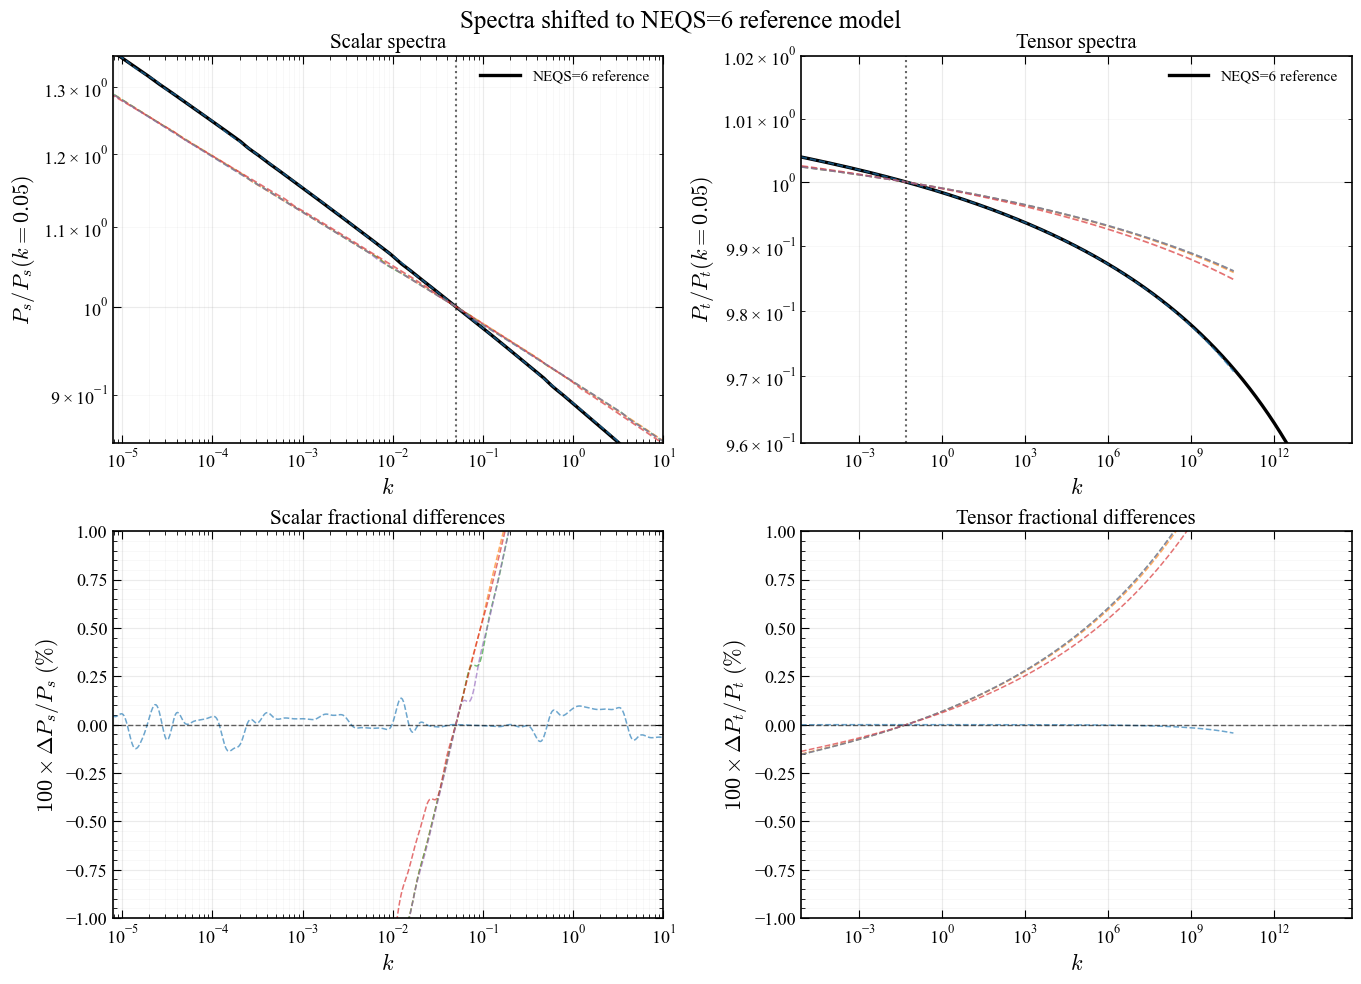


=== Cross-NEQS shifted spectra summary ===
 NEQS param_name        value  deltaN_from_ref_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
    9       lam6 6.100000e-10              9.825878      0.008500     0.137308     -0.004220     0.043145
    9       lam6 8.188894e-10              9.825878     -0.926917     4.973297      0.383834     1.519460
    9       lam6 1.570437e-09              9.825878     -0.955627     4.904683      0.389617     1.541593
    9       lam6 1.817399e-09              9.825878     -0.916260     5.071748      0.354397     1.406418
    9       lam6 3.257382e-09              9.825878     -0.969188     4.948805      0.389494     1.541196


In [42]:
lam_values_by_neqs = {
#     6: lam3_values,
    9: lam6_values,
}

all_shift_2x2_df = plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=base6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,

    # new y-limits
    frac_ylim=(-1, 1),
    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),

    save_name="rand_neqs9_lam5lam6_shifted_to_neqs6_base_spectra_2x2.png",
)


For those within a specific ns range:

In [43]:
def plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=-4.6097100000e-6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    zero_tol=1e-30,
    ns_min=None,
    ns_max=None,
    frac_ylim=(-0.6, 0.6),
    scalar_ylim=None,
    tensor_ylim=None,
    save_name=None,
):

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.labelsize": 16,
        "axes.titlesize": 15,
        "figure.titlesize": 18,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 11,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    colors_by_neqs = {
        5: "pink",
        6: "turquoise",
        7: "plum",
        8: "mediumslateblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def get_summary_row(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for "
                f"NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return matches.iloc[0]

    def get_original_N_end(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return float(row["original_N_end"])

    def get_ns_value(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return float(row["n_s"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside shifted k range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmax=None):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)

        k_use = k_ref_grid[mask]
        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    ref_N_end = get_original_N_end(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(
        k_s_ref_raw,
        Ps_ref_raw,
        k_norm,
    )

    k_t_ref, Pt_ref_norm = normalize_at_k(
        k_t_ref_raw,
        Pt_ref_raw,
        k_norm,
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.5, 9.5),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    mask_ref_s = k_s_ref <= k_max_scalar

    ax_ps.loglog(
        k_s_ref[mask_ref_s],
        Ps_ref_norm[mask_ref_s],
        color="black",
        lw=2.4,
        ls="-",
        label=rf"NEQS={ref_NEQS} reference",
    )

    ax_pt.loglog(
        k_t_ref,
        Pt_ref_norm,
        color="black",
        lw=2.4,
        ls="-",
        label=rf"NEQS={ref_NEQS} reference",
    )

    rows = []

    for NEQS, lam_values in lam_values_by_neqs.items():

        param_name, _ = SCAN_INFO[NEQS]
        color = colors_by_neqs.get(NEQS, None)

        for item in lam_values:

            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                ns_val = get_ns_value(
                    NEQS,
                    param_name,
                    value,
                )

                if ns_min is not None and ns_val < ns_min:
                    continue

                if ns_max is not None and ns_val > ns_max:
                    continue

                model_N_end = get_original_N_end(
                    NEQS,
                    param_name,
                    value,
                )

                deltaN = model_N_end - ref_N_end

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
                    NEQS,
                    param_name,
                    value,
                )

                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s, Ps_norm = normalize_at_k(
                    k_s_shifted,
                    Ps_raw,
                    k_norm,
                )

                k_t, Pt_norm = normalize_at_k(
                    k_t_shifted,
                    Pt_raw,
                    k_norm,
                )

                k_ps_err, frac_ps = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s,
                    Ps_norm,
                    kmax=k_max_scalar,
                )

                k_pt_err, frac_pt = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t,
                    Pt_norm,
                    kmax=None,
                )

                mask_s = k_s <= k_max_scalar

                ax_ps.loglog(
                    k_s[mask_s],
                    Ps_norm[mask_s],
                    color=color,
                    lw=1.25,
                    alpha=0.65,
                    ls="--",
                )

                ax_pt.loglog(
                    k_t,
                    Pt_norm,
                    color=color,
                    lw=1.25,
                    alpha=0.65,
                    ls="--",
                )

                ax_ps_err.semilogx(
                    k_ps_err,
                    100.0 * frac_ps,
                    color=color,
                    lw=1.1,
                    alpha=0.65,
                    ls="--",
                )

                ax_pt_err.semilogx(
                    k_pt_err,
                    100.0 * frac_pt,
                    color=color,
                    lw=1.1,
                    alpha=0.65,
                    ls="--",
                )

                rows.append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "n_s": ns_val,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "exp_minus_deltaN": np.exp(-deltaN),
                    "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                    "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                    "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                    "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.6,
        )

    ax_ps.axvline(k_norm, color="black", ls=":", alpha=0.6)
    ax_pt.axvline(k_norm, color="black", ls=":", alpha=0.6)

    for NEQS, color in colors_by_neqs.items():
        if NEQS in lam_values_by_neqs:
            ax_ps.plot(
                [],
                [],
                color=color,
                ls="--",
                lw=2,
                label=rf"NEQS={NEQS}",
            )

    ax_ps.set_title(r"Scalar spectra")
    ax_pt.set_title(r"Tensor spectra")
    ax_ps_err.set_title(r"Scalar fractional differences")
    ax_pt_err.set_title(r"Tensor fractional differences")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")
    ax_ps_err.set_ylabel(r"$100 \times \Delta P_s/P_s \; (\%)$")
    ax_pt_err.set_ylabel(r"$100 \times \Delta P_t/P_t \; (\%)$")

    ax_ps.set_xlim(k_s_ref.min(), k_max_scalar)
    ax_ps_err.set_xlim(k_s_ref.min(), k_max_scalar)

    ax_pt.set_xlim(k_t_ref.min(), k_t_ref.max())
    ax_pt_err.set_xlim(k_t_ref.min(), k_t_ref.max())

    ax_ps_err.set_ylim(*frac_ylim)
    ax_pt_err.set_ylim(*frac_ylim)

    if scalar_ylim is not None:
        ax_ps.set_ylim(*scalar_ylim)

    if tensor_ylim is not None:
        ax_pt.set_ylim(*tensor_ylim)

    for ax in axes.ravel():

        ax.minorticks_on()

        ax.grid(True, which="major", alpha=0.25, lw=0.8)
        ax.grid(True, which="minor", alpha=0.12, lw=0.5)

        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
        )

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                loc="best",
                handlelength=2.6,
                borderpad=0.4,
            )

    if ns_min is not None or ns_max is not None:
        ns_label = rf", $n_s \in [{ns_min}, {ns_max}]$"
    else:
        ns_label = ""

    fig.suptitle(
        rf"Spectra shifted to NEQS={ref_NEQS} reference model"
        rf"{ns_label}",
        y=1.02,
    )

    if save_name is None:
        save_name = (
            f"all_neqs_lamX_shifted_to_neqs"
            f"{ref_NEQS}_base_spectra_2x2.png"
        )

    plt.savefig(save_name)
    plt.show()

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:
        print("\n=== Cross-NEQS shifted spectra summary ===")
        print(
            stats_df[[
                "NEQS",
                "param_name",
                "value",
                "n_s",
                "deltaN_from_ref_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )
    else:
        print("\nNo models passed the requested filters.")

    return stats_df

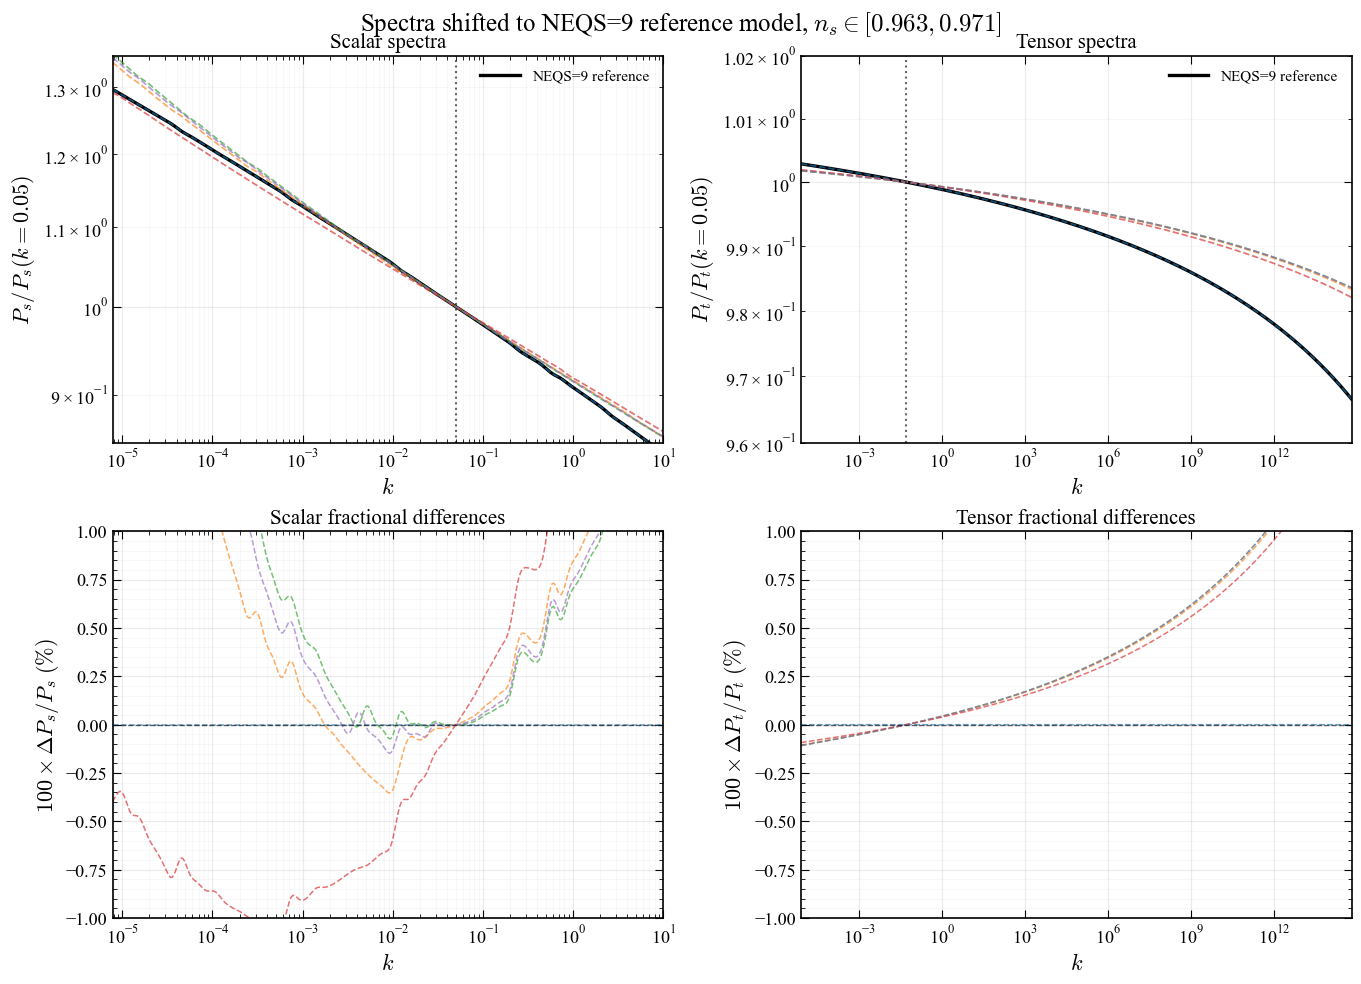


=== Cross-NEQS shifted spectra summary ===
 NEQS param_name        value      n_s  deltaN_from_ref_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
    9       lam6 6.100000e-10 0.970677                   0.0      0.000000     0.000000      0.000000     0.000000
    9       lam6 8.188894e-10 0.970677                   0.0      0.746269     3.277676      0.426415     1.735608
    9       lam6 1.570437e-09 0.970677                   0.0      0.985578     4.316017      0.433171     1.760993
    9       lam6 1.817399e-09 0.970677                   0.0      0.001921     2.600425      0.392457     1.606747
    9       lam6 3.257382e-09 0.970677                   0.0      0.898652     3.870789      0.433004     1.760468


In [48]:
all_shift_2x2_df = plot_all_neqs_kshift_to_lam3_base_2x2(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=9,
    ref_param="lam6",
    ref_value=base9,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    ns_min=0.963,
    ns_max=0.971,
    frac_ylim=(-1, 1),
    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),
    save_name="neqs6and8_ns_0p963_0p967_shifted_spectra_2x2.png",
)



## Testing trunctaion

In [78]:
SCAN_INFO = {
    7: ("lam4", r"\lambda_4"),
    8: ("lam5", r"\lambda_5"),
}

def prepare_increasing(k, P):
    order = np.argsort(k)
    return k[order], P[order]


def compute_shifted_errors_for_experiment(
    base_path_root,
    folder,
    NEQS,
    param_name,
    ref_folder="neqs6",
    ref_NEQS=6,
    ref_param="lam3",
    ref_value=-4.6097100000e-6,
    k_norm=0.05,
    k_max_scalar=10.0,
    skip_zero=True,
    zero_tol=1e-30,
):
    def model_folder(folder_name, neqs, param, value):
        return os.path.join(
            base_path_root,
            folder_name,
            f"{param}_{value:.10e}",
        )

    def load_specs(folder_name, neqs, param, value):
        folder_path = model_folder(folder_name, neqs, param, value)

        s = np.loadtxt(os.path.join(folder_path, f"spec_s_neqs{neqs}.dat"))
        t = np.loadtxt(os.path.join(folder_path, f"spec_t_neqs{neqs}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_summary(folder_name, neqs):
        return pd.read_csv(
            os.path.join(
                base_path_root,
                folder_name,
                f"neqs{neqs}_summary.csv",
            )
        )

    def get_summary_row(folder_name, neqs, param, value):
        df = load_summary(folder_name, neqs)
        matches = df.loc[np.isclose(df[param], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for {folder_name}, "
                f"NEQS={neqs}, {param}={value:.10e}"
            )

        return matches.iloc[0]

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_grid(k_ref, P_ref, k_cmp, P_cmp, kmax=None):
        k_ref, P_ref = prepare_increasing(k_ref, P_ref)
        k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

        xmin = max(k_ref.min(), k_cmp.min())
        xmax = min(k_ref.max(), k_cmp.max())
        
        if xmin >= xmax:
            return np.array([]), np.array([])

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_ref >= xmin) & (k_ref <= xmax)

        k_use = k_ref[mask]
        P_ref_use = P_ref[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    # Reference model
    ref_row = get_summary_row(
        ref_folder,
        ref_NEQS,
        ref_param,
        ref_value,
    )

    ref_N_end = float(ref_row["original_N_end"])

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_folder,
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(
        k_s_ref_raw,
        Ps_ref_raw,
        k_norm,
    )

    k_t_ref, Pt_ref_norm = normalize_at_k(
        k_t_ref_raw,
        Pt_ref_raw,
        k_norm,
    )

    # Current experiment values
    summary_df = load_summary(folder, NEQS)

    values = summary_df[param_name].values

    rows = []

    for value in values:
        value = float(value)

        if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
            continue

        try:
            row = get_summary_row(folder, NEQS, param_name, value)

            model_N_end = float(row["original_N_end"])
            deltaN = model_N_end - ref_N_end

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                folder,
                NEQS,
                param_name,
                value,
            )

            k_s_shifted = k_s_raw * np.exp(-deltaN)
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            k_s, Ps_norm = normalize_at_k(
                k_s_shifted,
                Ps_raw,
                k_norm,
            )

            k_t, Pt_norm = normalize_at_k(
                k_t_shifted,
                Pt_raw,
                k_norm,
            )

            k_ps_err, frac_ps = frac_on_grid(
                k_s_ref,
                Ps_ref_norm,
                k_s,
                Ps_norm,
                kmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_grid(
                k_t_ref,
                Pt_ref_norm,
                k_t,
                Pt_norm,
                kmax=None,
            )

            if len(frac_ps) == 0:
                print(
                    f"Skipping {folder}, {param_name}={value:.10e}: "
                    f"no scalar k-overlap after N-shift"
                )
                continue

            if len(frac_pt) == 0:
                print(
                    f"Skipping {folder}, {param_name}={value:.10e}: "
                    f"no tensor k-overlap after N-shift"
                )
                continue

            rows.append({
                "folder": folder,
                "NEQS": NEQS,
                "param_name": param_name,
                "value": value,
                "n_s": row.get("n_s", np.nan),
                "original_N_end": model_N_end,
                "deltaN_from_ref_base": deltaN,
                "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
            })

        except Exception as e:
            print(f"Skipping {folder}, {param_name}={value:.10e}: {e}")

    return pd.DataFrame(rows)


def summarize_experiment(df, label):
    return {
        "label": label,
        "n_models": len(df),

        "mean_abs_dPs_pct": np.nanmean(np.abs(df["mean_dPs_pct"])),
        "max_dPs_pct": np.nanmax(np.abs(df["max_dPs_pct"])),

        "mean_abs_dPt_pct": np.nanmean(np.abs(df["mean_dPt_pct"])),
        "max_dPt_pct": np.nanmax(np.abs(df["max_dPt_pct"])),
    }


def plot_truncation_error_summary(
    summary_rows,
    tolerance=1.0,
    save_name=None,

    scalar_mean_color="turquoise",
    scalar_max_color="mediumslateblue",

    tensor_mean_color="plum",
    tensor_max_color="pink",
):
    
    
    summary_df = pd.DataFrame(summary_rows)

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    x = np.arange(len(summary_df))
    width = 0.20

    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

    ax.bar(
    x - 1.5 * width,
    summary_df["mean_abs_dPs_pct"],
    width,
    color=scalar_mean_color,
    label=r"mean $|\Delta P_s/P_s|$",
    )

    ax.bar(
        x - 0.5 * width,
        summary_df["max_dPs_pct"],
        width,
        color=scalar_max_color,
        label=r"max $|\Delta P_s/P_s|$",
    )

    ax.bar(
        x + 0.5 * width,
        summary_df["mean_abs_dPt_pct"],
        width,
        color=tensor_mean_color,
        label=r"mean $|\Delta P_t/P_t|$",
    )

    ax.bar(
        x + 1.5 * width,
        summary_df["max_dPt_pct"],
        width,
        color=tensor_max_color,
        label=r"max $|\Delta P_t/P_t|$",
    )

    ax.axhline(
        tolerance,
        color="black",
        ls="--",
        lw=1.2,
        label=rf"{tolerance:.1f}\% tolerance",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        summary_df["label"],
        rotation=25,
        ha="right",
    )

    ax.set_ylabel(r"fractional error after $N$-shift $(\%)$")
    ax.set_title(r"Truncation stability of shifted primordial spectra", fontsize=20)

    ax.set_yscale("log")
    ax.grid(True, which="major", axis="y", alpha=0.25)
    ax.grid(True, which="minor", axis="y", alpha=0.12)

    ax.legend(
    frameon=False,
    ncol=2,
    fontsize=18,
    )
    
#     legend = ax.legend(
#     frameon=False,
#     ncol=2,
#     fontsize=14,
#     title="Shifted Spectral Errors",
#     )

#     legend.get_title().set_fontsize(15)

    if save_name is not None:
#         plt.savefig(save_name)

    plt.show()

    return summary_df

IndentationError: expected an indented block after 'if' statement on line 337 (62003680.py, line 340)

Skipping neqs7_largekinney, lam4=4.7381869685e-04: no scalar k-overlap after N-shift
Skipping neqs7_largekinney, lam4=2.2433356388e-04: no scalar k-overlap after N-shift
Skipping neqs8_largekinney, lam5=-3.2812211689e-05: no scalar k-overlap after N-shift


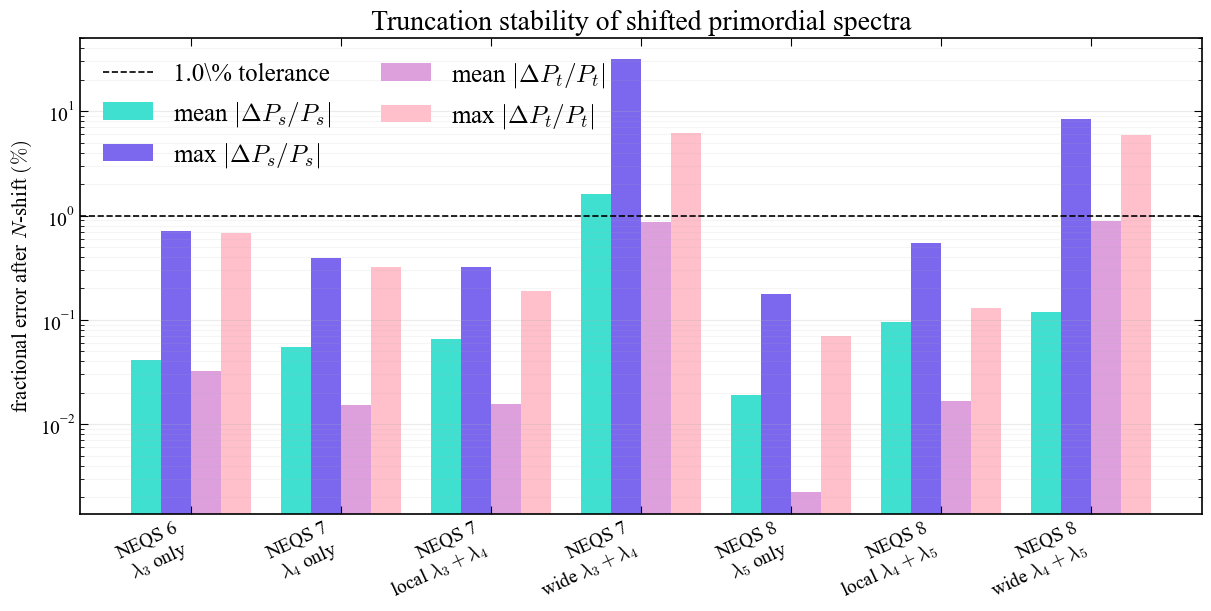

                              label  n_models  mean_abs_dPs_pct  max_dPs_pct  mean_abs_dPt_pct  max_dPt_pct
           NEQS 6\n$\lambda_3$ only        39          0.041290     0.714596          0.032710     0.684802
           NEQS 7\n$\lambda_4$ only        39          0.055524     0.390538          0.015383     0.321816
NEQS 7\nlocal $\lambda_3+\lambda_4$         5          0.065966     0.320675          0.015653     0.190383
 NEQS 7\nwide $\lambda_3+\lambda_4$         3          1.606682    31.432288          0.871929     6.136019
           NEQS 8\n$\lambda_5$ only         4          0.018950     0.175395          0.002235     0.070482
NEQS 8\nlocal $\lambda_4+\lambda_5$         5          0.095216     0.547765          0.016602     0.130745
 NEQS 8\nwide $\lambda_4+\lambda_5$        39          0.119300     8.503790          0.880707     5.875642


In [79]:
base_path_root = (
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
)

experiments = [
    {
        "label": "NEQS 6\n" + r"$\lambda_3$ only",
        "folder": "neqs6",
        "NEQS": 6,
        "param_name": "lam3",
    },
    {
        "label": "NEQS 7\n" + r"$\lambda_4$ only",
        "folder": "neqs7",
        "NEQS": 7,
        "param_name": "lam4",
    },
    {
        "label": "NEQS 7\n" + r"local $\lambda_3+\lambda_4$",
        "folder": "neqs7_narrow",
        "NEQS": 7,
        "param_name": "lam4",
    },
    {
        "label": "NEQS 7\n" + r"wide $\lambda_3+\lambda_4$",
        "folder": "neqs7_largekinney",
        "NEQS": 7,
        "param_name": "lam4",
    },
    {
        "label": "NEQS 8\n" + r"$\lambda_5$ only",
        "folder": "neqs8",
        "NEQS": 8,
        "param_name": "lam5",
    },
    {
        "label": "NEQS 8\n" + r"local $\lambda_4+\lambda_5$",
        "folder": "neqs8_narrow",
        "NEQS": 8,
        "param_name": "lam5",
    },
    {
        "label": "NEQS 8\n" + r"wide $\lambda_4+\lambda_5$",
        "folder": "neqs8_largekinney",
        "NEQS": 8,
        "param_name": "lam5",
    },
]

all_dfs = {}
summary_rows = []

for exp in experiments:
    df = compute_shifted_errors_for_experiment(
        base_path_root=base_path_root,
        folder=exp["folder"],
        NEQS=exp["NEQS"],
        param_name=exp["param_name"],

        ref_folder="neqs6",
        ref_NEQS=6,
        ref_param="lam3",
        ref_value=-4.6097100000e-6,

        k_norm=0.05,
        k_max_scalar=1.0,
        skip_zero=True,
    )

    all_dfs[exp["folder"]] = df

    summary_rows.append(
        summarize_experiment(
            df=df,
            label=exp["label"],
        )
    )

truncation_summary_df = plot_truncation_error_summary(
    summary_rows,
    tolerance=1.0,

    scalar_mean_color="turquoise",
    scalar_max_color="mediumslateblue",

    tensor_mean_color="plum",
    tensor_max_color="pink",

    save_name="truncation_error_summary.png",
)
print(truncation_summary_df.to_string(index=False))

In [102]:
def plot_deltaN_vs_error_2panel(
    all_dfs,
    experiment_labels,
    tolerance=1.0,
    save_name=None,
):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.labelsize": 18,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(15, 7.5),
        constrained_layout=True,
        sharex=True,
    )

    for folder, df in all_dfs.items():

        if df.empty:
            continue

        label = experiment_labels.get(folder, folder)

        # Scalar
        ax1.scatter(
            df["deltaN_from_ref_base"],
            np.abs(df["max_dPs_pct"]),
            s=55,
            alpha=0.8,
            label=label,
        )

        # Tensor
        ax2.scatter(
            df["deltaN_from_ref_base"],
            np.abs(df["max_dPt_pct"]),
            s=55,
            alpha=0.8,
            label=label,
        )

    # Scalar panel
    ax1.axhline(
        tolerance,
        color="black",
        ls="--",
        lw=1.2,
    )

    ax1.axvline(
        0.0,
        color="black",
        ls=":",
        lw=1.0,
        alpha=0.7,
    )

    ax1.set_yscale("log")

    ax1.set_xlabel(r"$\Delta N$")
    ax1.set_ylabel(
        r"max $|\Delta P_s/P_s|$ (%)"
    )

    ax1.set_title(
        r"Scalar spectrum error", fontsize=20
    )

    ax1.grid(True, which="major", alpha=0.25)
    ax1.grid(True, which="minor", alpha=0.12)

    # Tensor panel
    ax2.axhline(
        tolerance,
        color="black",
        ls="--",
        lw=1.2,
    )

    ax2.axvline(
        0.0,
        color="black",
        ls=":",
        lw=1.0,
        alpha=0.7,
    )

    ax2.set_yscale("log")

    ax2.set_xlabel(r"$\Delta N$")
    ax2.set_ylabel(
        r"max $|\Delta P_t/P_t|$ (%)"
    )

    ax2.set_title(
        r"Tensor spectrum error", fontsize=20
    )

    ax2.grid(True, which="major", alpha=0.25)
    ax2.grid(True, which="minor", alpha=0.12)

    # One legend for both panels
    handles, labels = ax1.get_legend_handles_labels()

    fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=16,
)

    # Label the tolerance line
    ax1.text(
        0.98,
        tolerance * 1.1,
        "1% threshold",
        transform=ax1.get_yaxis_transform(),
        ha="right",
        fontsize=14,
    )

    ax2.text(
        0.98,
        tolerance * 1.1,
        "1% threshold",
        transform=ax2.get_yaxis_transform(),
        ha="right",
        fontsize=14,
    )

    if save_name is not None:
        plt.savefig(
            save_name,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

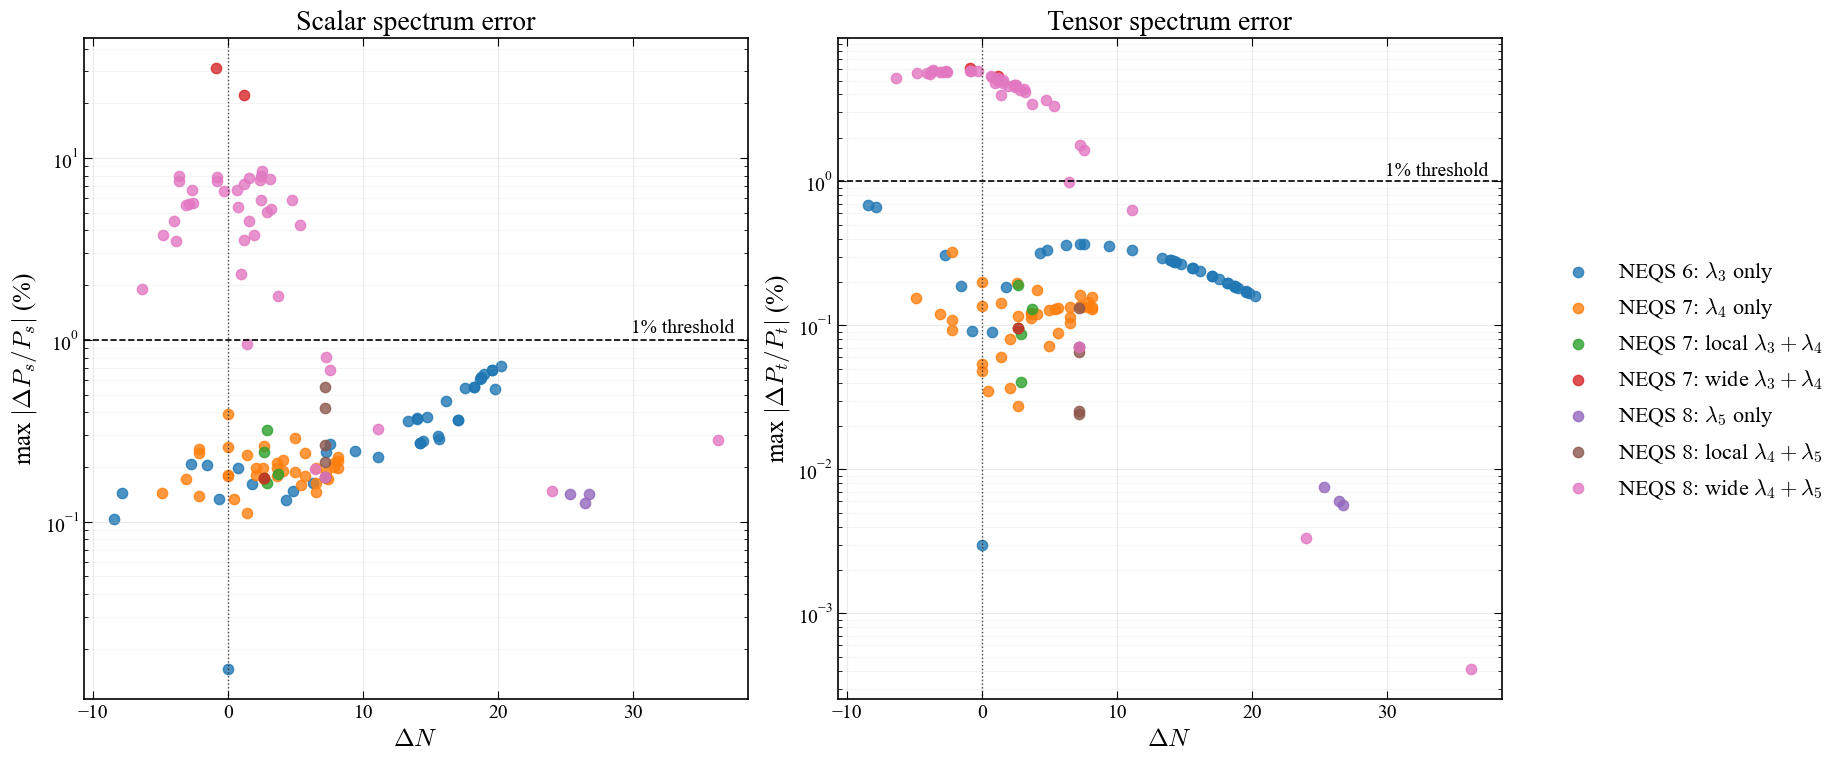

In [103]:
experiment_labels = {
    "neqs6": r"NEQS 6: $\lambda_3$ only",
    "neqs7": r"NEQS 7: $\lambda_4$ only",
    "neqs7_narrow": r"NEQS 7: local $\lambda_3+\lambda_4$",
    "neqs7_largekinney": r"NEQS 7: wide $\lambda_3+\lambda_4$",
    "neqs8": r"NEQS 8: $\lambda_5$ only",
    "neqs8_narrow": r"NEQS 8: local $\lambda_4+\lambda_5$",
    "neqs8_largekinney": r"NEQS 8: wide $\lambda_4+\lambda_5$",
}

plot_deltaN_vs_error_2panel(
    all_dfs,
    experiment_labels,
    tolerance=1.0,
    save_name="deltaN_vs_error_2panel.png",
)